In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv('balanced_dataset_marks_capped_5000.csv')

In [ ]:
df.head()

,total_time,waited_time,total_q,answered,correct,wrong,marks,accuracy,error_rate,speed,engagement,attempt_rate,correct_ratio,wrong_ratio,time_per_question,wait_ratio,normalized_score,recommended_difficulty,recommended_count
0,36,30.2,25,5,3,2,3,0.6000,0.4000,0.1389,0.1600,0.2000,0.1200,0.0800,7.2000,0.8400,0.03,Easy,3
1,27,12.8,37,21,17,4,17,0.8095,0.1905,0.7778,0.5269,0.5676,0.4595,0.1081,1.2857,0.4731,0.17,Medium,19
2,46,3.1,28,25,15,10,75,0.6000,0.4000,0.5435,0.9329,0.8929,0.5357,0.3571,1.8400,0.0671,0.75,Medium,31
3,111,46.7,37,20,20,0,100,1.0000,0.0000,0.1802,0.5795,0.5405,0.5405,0.0000,5.5500,0.4205,1.00,Hard,23
4,32,5.7,16,11,9,2,18,0.8182,0.1818,0.3438,0.8204,0.6875,0.5625,0.1250,2.9091,0.1796,0.18,Hard,12


In [ ]:
df['total_time'].mean()

np.float64(70.1532613045218)

Total numeric columns: 18
Columns: ['total_time', 'waited_time', 'total_q', 'answered', 'correct', 'wrong', 'marks', 'accuracy', 'error_rate', 'speed', 'engagement', 'attempt_rate', 'correct_ratio', 'wrong_ratio', 'time_per_question', 'wait_ratio', 'normalized_score', 'recommended_count']


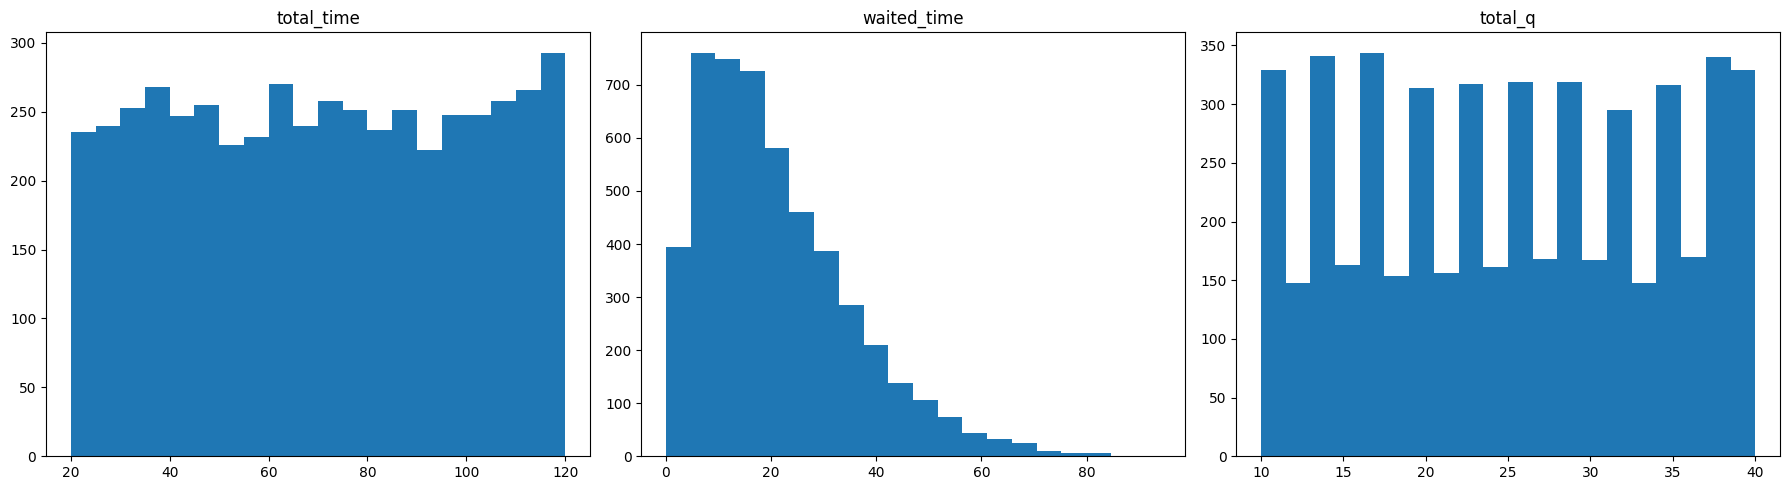

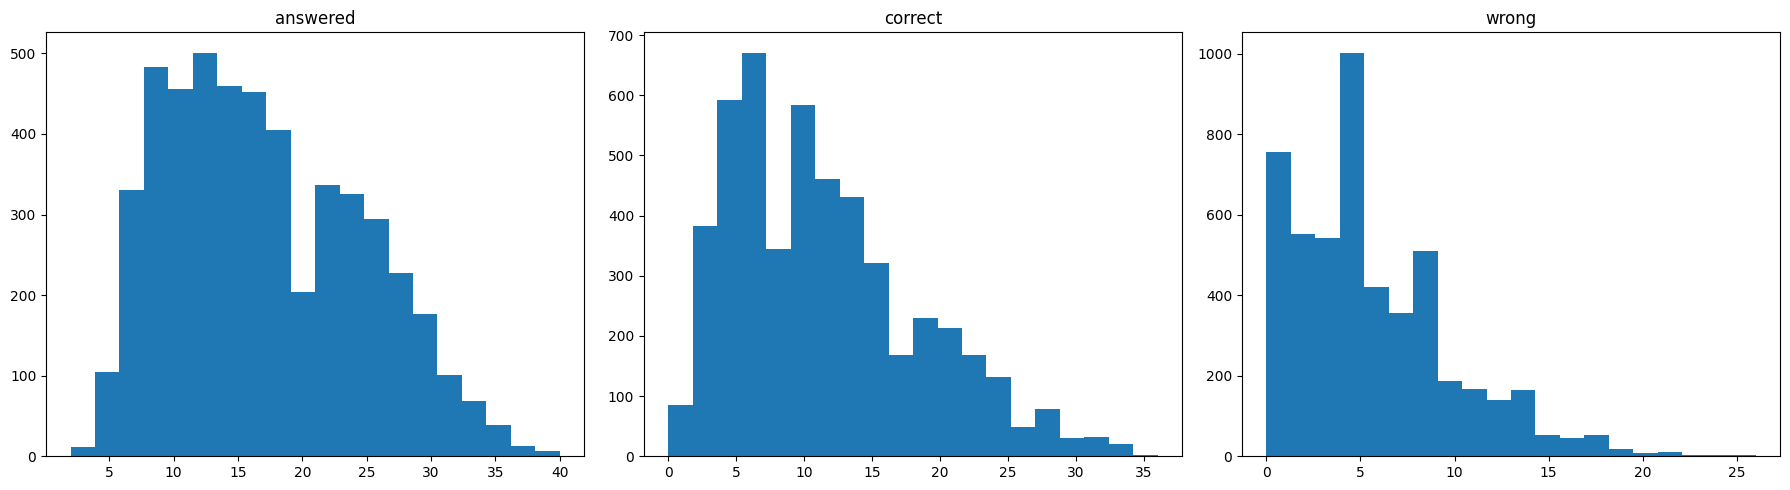

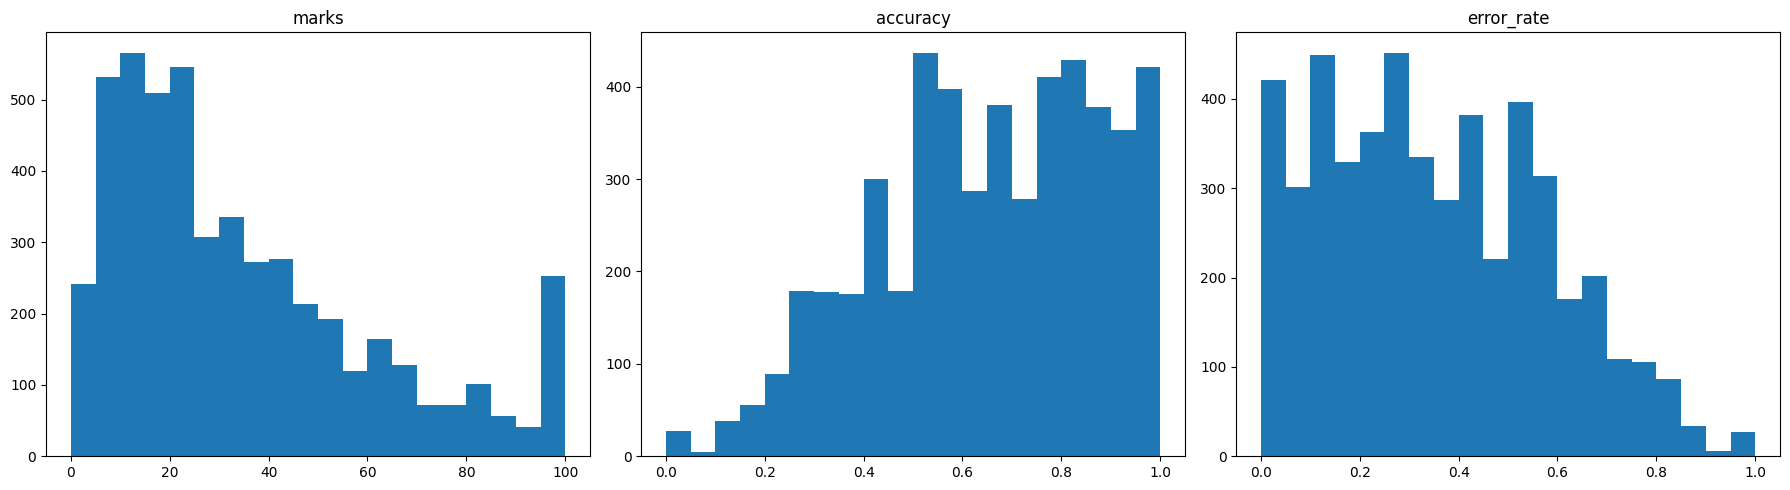

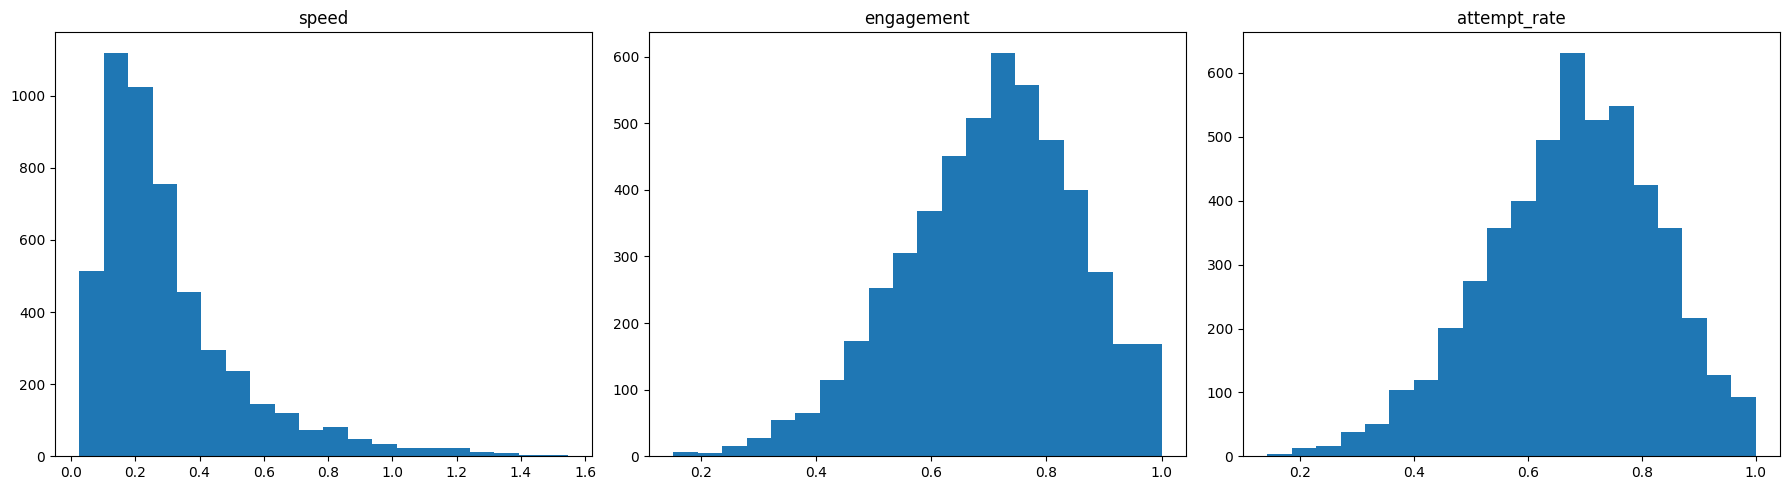

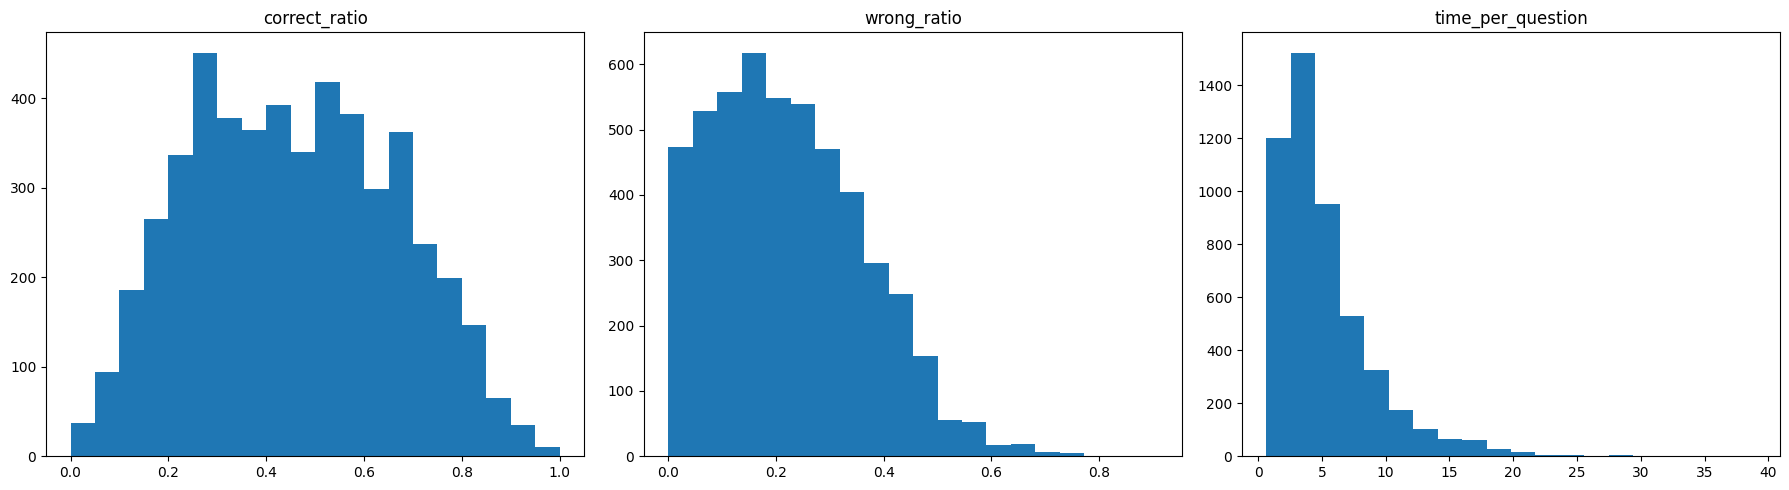

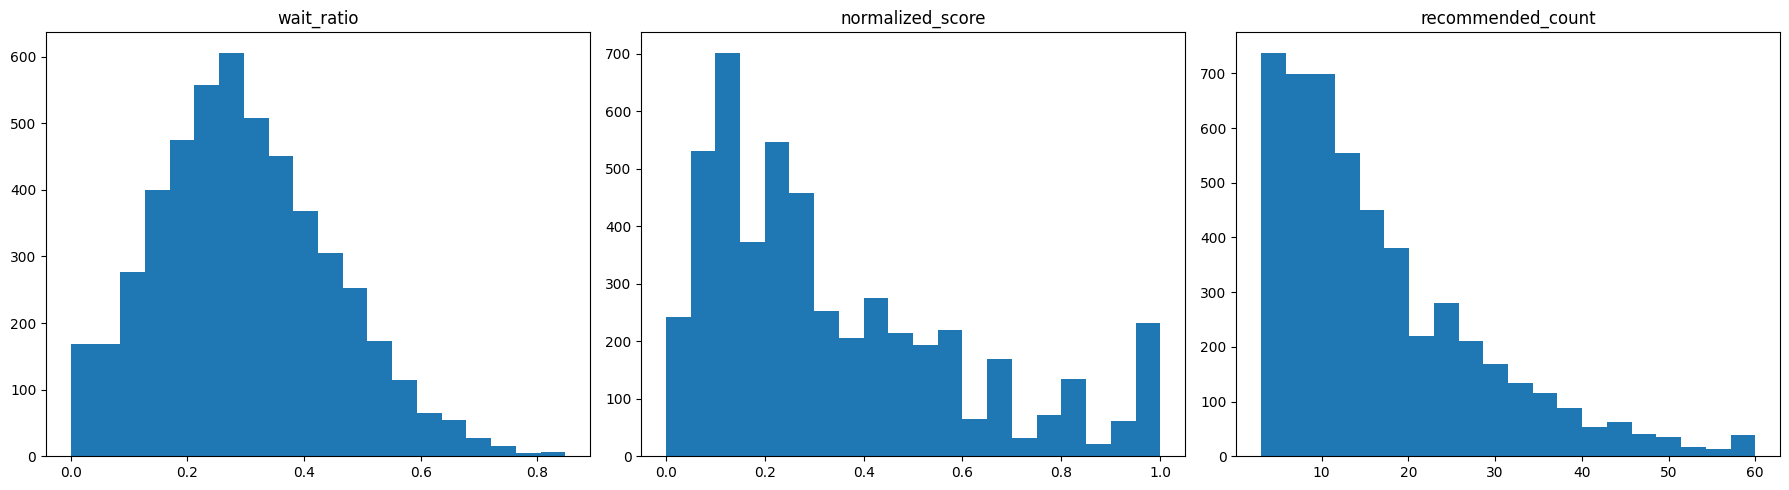

In [ ]:
# Select numeric columns only
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()

print("Total numeric columns:", len(numeric_cols))
print("Columns:", numeric_cols)

# Number of plots per row
plots_per_row = 3

for i, col in enumerate(numeric_cols):

    # Start a new figure for each row (every 3 plots)
    if i % plots_per_row == 0:
        if i != 0:  # show previous figure
            plt.tight_layout()
            plt.show()
        plt.figure(figsize=(18, 5))

    # Position inside the current row figure
    subplot_index = (i % plots_per_row) + 1
    plt.subplot(1, plots_per_row, subplot_index)

    # Plot histogram
    plt.hist(df[col], bins=20)
    plt.title(col)
    plt.xlabel("")
    plt.ylabel("")

# Show the last figure
plt.tight_layout()
plt.show()

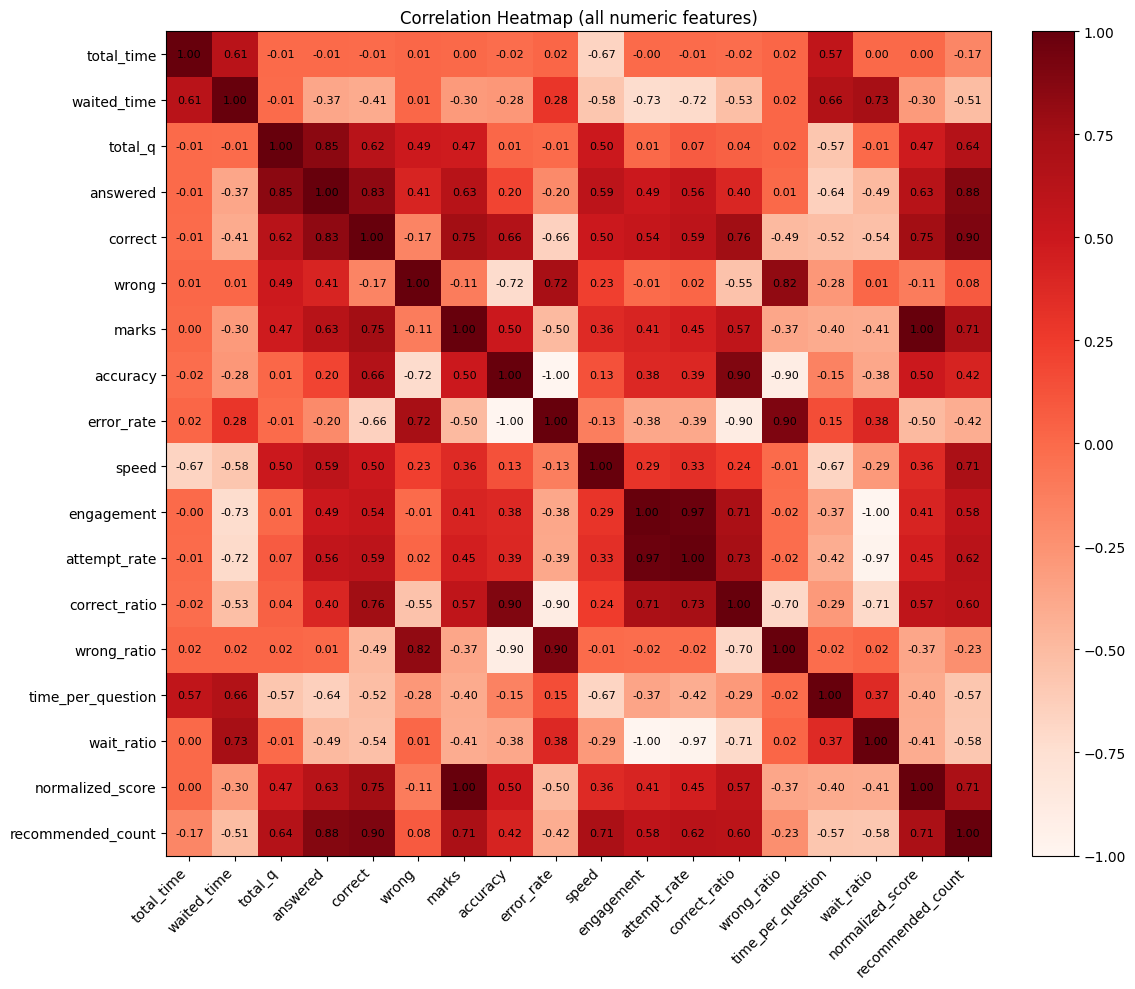

In [ ]:
import numpy as np

# Keep numeric columns only (correlation needs numeric values)
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
corr = df[num_cols].corr()

# Plot
plt.figure(figsize=(12, 10))
im = plt.imshow(corr, interpolation='nearest', cmap='Reds')   # default colormap
plt.colorbar(im, fraction=0.046, pad=0.04)

# ticks and labels
n = len(num_cols)
plt.xticks(range(n), num_cols, rotation=45, ha='right')
plt.yticks(range(n), num_cols)

# annotate each cell with correlation value
for i in range(n):
    for j in range(n):
        plt.text(j, i, f"{corr.iloc[i, j]:.2f}", ha='center', va='center', fontsize=8)

plt.title("Correlation Heatmap (all numeric features)")
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras import layers, Model
import joblib


feature_cols = [
    "total_time","waited_time","total_q","answered","correct","wrong","marks",
    "accuracy","error_rate","speed","engagement","attempt_rate",
    "correct_ratio","wrong_ratio","time_per_question","wait_ratio","normalized_score"
]

X = df[feature_cols].values

label_encoder = LabelEncoder()
y_class = label_encoder.fit_transform(df["recommended_difficulty"])


y_reg = df["recommended_count"].values

X_train, X_test, y_class_train, y_class_test, y_reg_train, y_reg_test = train_test_split(
    X, y_class, y_reg, test_size=0.20, random_state=42
)


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
inputs = layers.Input(shape=(X_train_scaled.shape[1],))

# Shared Layers
x = layers.Dense(64, activation="relu")(inputs)
x = layers.Dense(32, activation="relu")(x)

# Classification branch
class_branch = layers.Dense(16, activation="relu")(x)
class_output = layers.Dense(len(label_encoder.classes_), activation="softmax", name="difficulty")(class_branch)

# Regression branch
reg_branch = layers.Dense(16, activation="relu")(x)
reg_output = layers.Dense(1, activation="linear", name="question_count")(reg_branch)

# Build final model
model = Model(inputs=inputs, outputs=[class_output, reg_output])

# Compile
model.compile(
    optimizer="adam",
    loss={
        "difficulty": "sparse_categorical_crossentropy",
        "question_count": "mse"
    },
    metrics={
        "difficulty": "accuracy",
        "question_count": "mae"
    }
)

model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 17)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │      1,152 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 32)        │      2,080 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 16)        │        528 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 16)        │        528 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ difficulty (Dense)  │ (None, 3)         │         51 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ question_count      │ (None, 1)         │         17 │ dense_3[0][0]     │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 4,356 (17.02 KB)

 Trainable params: 4,356 (17.02 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

history = model.fit(
    X_train_scaled,
    {"difficulty": y_class_train, "question_count": y_reg_train},
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop]
)


Epoch 1/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - difficulty_accuracy: 0.3763 - difficulty_loss: 1.1340 - loss: 336.8250 - question_count_loss: 335.6886 - question_count_mae: 14.4448 - val_difficulty_accuracy: 0.6450 - val_difficulty_loss: 0.7365 - val_loss: 18.5984 - val_question_count_loss: 17.8619 - val_question_count_mae: 3.3555
Epoch 2/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - difficulty_accuracy: 0.6523 - difficulty_loss: 0.7418 - loss: 15.6696 - question_count_loss: 14.9277 - question_count_mae: 3.0604 - val_difficulty_accuracy: 0.6662 - val_difficulty_loss: 0.7080 - val_loss: 10.4073 - val_question_count_loss: 9.6992 - val_question_count_mae: 2.4510
Epoch 3/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - difficulty_accuracy: 0.6622 - difficulty_loss: 0.7085 - loss: 9.7978 - question_count_loss: 9.0893 - question_count_mae: 2.3706 - val_difficulty_accuracy: 0.6888 - val_difficulty_loss: 0.6848 - val_loss: 8.4074 - val_question_count_loss: 7.7226 - val_question_count_mae

In [ ]:
results = model.evaluate(X_test_scaled, {"difficulty": y_class_test, "question_count": y_reg_test})
print("\nTest Results:", results)

model.save("student_recommender_model.h5")
joblib.dump(scaler, "student_recommender_scaler.pkl")
joblib.dump(label_encoder, "student_recommender_label_encoder.pkl")

print("\nModel training complete. Files saved:")
print(" - student_recommender_model.h5")
print(" - scaler.pkl")
print(" - label_encoder.pkl")

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - difficulty_accuracy: 0.6852 - difficulty_loss: 0.6661 - loss: 4.5904 - question_count_loss: 3.9256 - question_count_mae: 1.5954



Test Results: [4.616403102874756, 0.6381227374076843, 4.0005927085876465, 0.6919999718666077, 1.5927470922470093]

Model training complete. Files saved:
 - student_recommender_model.h5
 - scaler.pkl
 - label_encoder.pkl


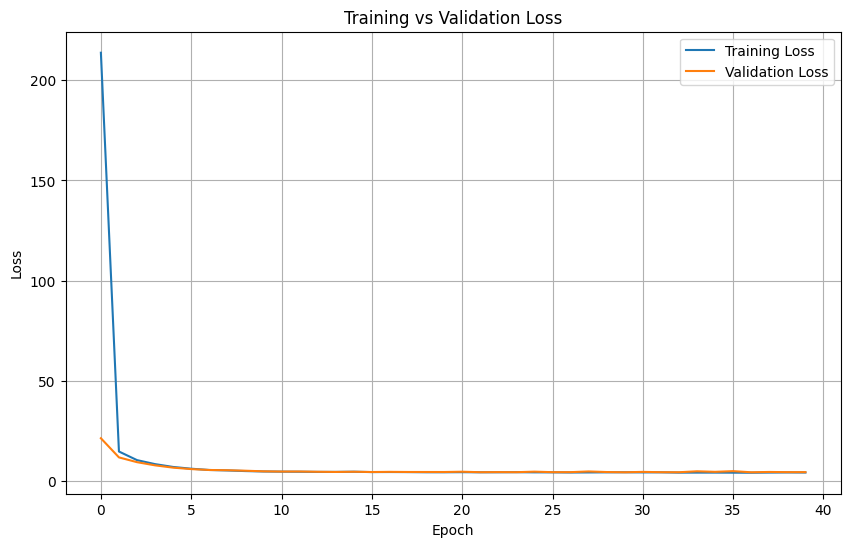

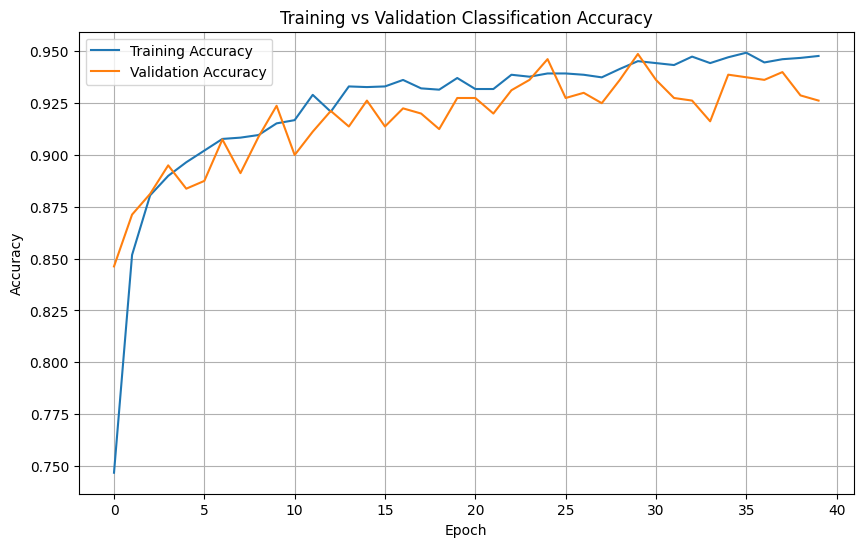

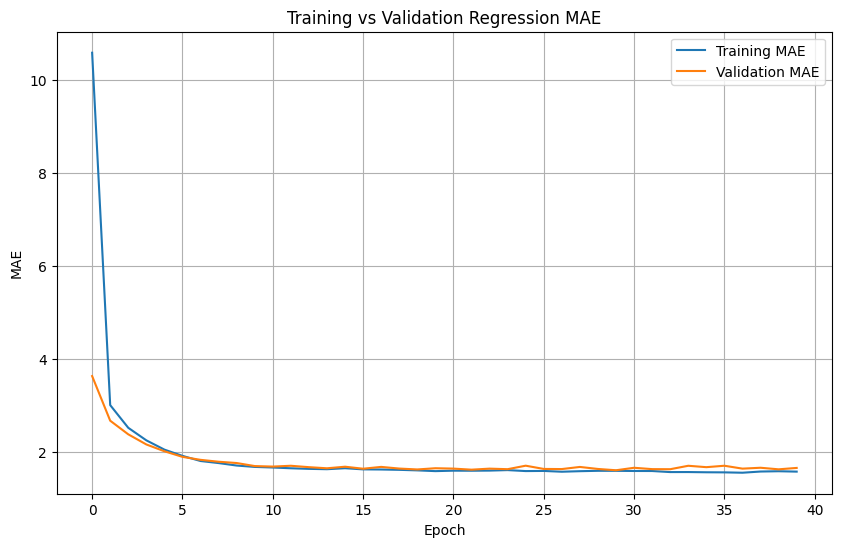

In [ ]:
import matplotlib.pyplot as plt

def plot_history(history):
  # PLOT TRAINING & VALIDATION LOSS
  plt.figure(figsize=(10, 6))
  plt.plot(history.history["loss"], label="Training Loss")
  plt.plot(history.history["val_loss"], label="Validation Loss")
  plt.xlabel("Epoch")
  plt.ylabel("Loss")
  plt.title("Training vs Validation Loss")
  plt.legend()
  plt.grid(True)
  plt.show()

  # PLOT TRAINING & VALIDATION ACCURACY (Difficulty Classification)
  plt.figure(figsize=(10, 6))
  plt.plot(history.history["difficulty_accuracy"], label="Training Accuracy")
  plt.plot(history.history["val_difficulty_accuracy"], label="Validation Accuracy")
  plt.xlabel("Epoch")
  plt.ylabel("Accuracy")
  plt.title("Training vs Validation Classification Accuracy")
  plt.legend()
  plt.grid(True)
  plt.show()

  # PLOT TRAINING & VALIDATION MAE (Question Count Regression)
  plt.figure(figsize=(10, 6))
  plt.plot(history.history["question_count_mae"], label="Training MAE")
  plt.plot(history.history["val_question_count_mae"], label="Validation MAE")
  plt.xlabel("Epoch")
  plt.ylabel("MAE")
  plt.title("Training vs Validation Regression MAE")
  plt.legend()
  plt.grid(True)
  plt.show()

plot_history(history)

In [ ]:
def build_model_input(
    total_time,
    waited_time,
    total_q,
    answered,
    correct,
    wrong,
    marks
):

    accuracy = correct / answered if answered > 0 else 0
    error_rate = wrong / answered if answered > 0 else 0
    speed = answered / total_time if total_time > 0 else 0
    engagement = 1 - (waited_time / total_time) if total_time > 0 else 0
    attempt_rate = answered / total_q if total_q > 0 else 0
    correct_ratio = correct / total_q if total_q > 0 else 0
    wrong_ratio = wrong / total_q if total_q > 0 else 0
    time_per_question = total_time / answered if answered > 0 else total_time
    wait_ratio = waited_time / total_time if total_time > 0 else 0
    normalized_score = marks / 100


    input_array = np.array([[
        total_time,
        waited_time,
        total_q,
        answered,
        correct,
        wrong,
        marks,
        accuracy,
        error_rate,
        speed,
        engagement,
        attempt_rate,
        correct_ratio,
        wrong_ratio,
        time_per_question,
        wait_ratio,
        normalized_score
    ]])

    return input_array

In [ ]:
import numpy as np
import tensorflow as tf
import joblib

# Define custom objects for loading the model
custom_objects = {
    'mse': tf.keras.losses.mse,
    'mae': tf.keras.metrics.mae
}

# Load model + tools (run once, outside the function)
model = tf.keras.models.load_model("student_recommender_model.h5", custom_objects=custom_objects)
scaler = joblib.load("scaler.pkl")
label_encoder = joblib.load("label_encoder.pkl")

def predict_recommendation(
    total_time,
    waited_time,
    total_q,
    answered,
    correct,
    wrong,
    marks
):
    # ---- Derived Features ----
    accuracy = correct / answered if answered > 0 else 0
    error_rate = wrong / answered if answered > 0 else 0
    speed = answered / total_time if total_time > 0 else 0
    engagement = 1 - (waited_time / total_time) if total_time > 0 else 0
    attempt_rate = answered / total_q if total_q > 0 else 0
    correct_ratio = correct / total_q if total_q > 0 else 0
    wrong_ratio = wrong / total_q if total_q > 0 else 0
    time_per_question = total_time / answered if answered > 0 else total_time
    wait_ratio = waited_time / total_time if total_time > 0 else 0
    normalized_score = marks / 100  # marks capped 0-100

    # ---- Input array (same order as training) ----
    X = np.array([[
        total_time,
        waited_time,
        total_q,
        answered,
        correct,
        wrong,
        marks,
        accuracy,
        error_rate,
        speed,
        engagement,
        attempt_rate,
        correct_ratio,
        wrong_ratio,
        time_per_question,
        wait_ratio,
        normalized_score
    ]])

    # ---- Scale ----
    X_scaled = scaler.transform(X)

    # ---- Predict ----
    pred_class, pred_count = model.predict(X_scaled)

    # ---- Decode outputs ----
    difficulty = label_encoder.inverse_transform([np.argmax(pred_class)])[0]
    question_count = int(pred_count[0][0])

    return difficulty, question_count

In [ ]:
difficulty, qcount = predict_recommendation(
    total_time=60,
    waited_time=1,
    total_q=25,
    answered=25,
    correct=23,
    wrong=2,
    marks=95
)

print("Recommended Difficulty:", difficulty)
print("Recommended Question Count:", qcount)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
Recommended Difficulty: Hard
Recommended Question Count: 37
